In [1]:
from mnesis_boilerplate import torch, np, data_cache, Path, RECOMPUTE, DEBUG, get_scores, printfig, approx_equals, SubplotParams, pprint, splt, i_pattern, phi, figpath, Params, asdict, loss_fn, pd, plt, sns
from mnesis_chains import SpikingPattern, HD_SNN
# RECOMPUTE = True

# corpus length: 8e+09 characters
# n_char = 10_000_000
# n_char = 100_000_000
# n_char = 500_000
# n_char = 1_000_000_000
exp = f'text_alice' # HACK
exp

datetag = '2026-08-06'
Using device: mps


'text_alice'

In [2]:
opt_dict = dict(N_neuron=512, N_time=1000, 
                N_pattern=16, num_delay=61, N_pretime=0,
                lif_beta=0.4, p_A=0., 
                lif_threshold=.80, do_pinv=True,
                num_epochs=1024, )
opt = Params(**opt_dict)
opt

Params(datetag='2026-08-06', N_neuron=512, num_delay=61, N_pattern=16, N_time=1000, N_pretime=0, p_A=0.0, p_flip=0.01, seed=2018, lif_beta=0.4, lif_threshold=0.8, learn_beta=False, learn_threshold=False, do_pinv=True, do_deconv=True, num_epochs=1024, num_warmup_epochs=16, base_lr=0.03, final_lr=0.001, delta1=0.01, delta2=1e-05, dropout=0.25, alpha_surrogate=5.0, surrogate_name='FastSigmoid', loss_name='SpikeF1scoreLoss', reset_mechanism='subtract', optimizer='sgd', verbose=False, fig_width=30, fig_height=15, phi=1.61803, N_time_show=512, N_neuron_show=200, N_scan=36)

# working memory with text



### getting text: Wikipedia

In [3]:
# %pip install -q -U datasets  

In [4]:
# filename = data_cache / f"wikipedia_dataset.parquet"

# if not filename.exists() or RECOMPUTE:
#     from datasets import load_dataset
#     # Load the French Wikipedia dataset
#     dataset = load_dataset("wikimedia/wikipedia", "20231101.fr")["train"]
#     dataset.to_parquet(filename)

# dataset = pd.read_parquet(filename)
# dataset.info()

In [5]:
# print(f"Total number of articles: {len(dataset)}")

In [6]:
# print(dataset["text"][:500])

In [7]:
# dataset['text'][:5]

In [8]:
# len(dataset)

In [9]:
# NeuroComp_text = dataset[dataset["title"] == "Neurosciences computationnelles"]["text"].iloc[0]


autre solution https://www.gutenberg.org/cache/epub/11/pg11.txt


In [10]:
# Load the Alice in Wonderland text
filename = data_cache / f"alice_in_wonderland.txt"

try:
    text_of_alice = filename.read_text(encoding="utf-8")   # pathlib shortcut
except FileNotFoundError:
    print(f"❌  File not found: {filename}")
except OSError as e:
    print(f"❌  Could not read the file: {e}")

n_char = len(text_of_alice)
print(f"Total number of characters in Alice in Wonderland: {n_char}")

Total number of characters in Alice in Wonderland: 163013


In [11]:
print(text_of_alice[500:1500])

R XII.   Alice’s Evidence




CHAPTER I.
Down the Rabbit-Hole


Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, “and what is the use of a book,” thought Alice
“without pictures or conversations?”

So she was considering in her own mind (as well as she could, for the
hot day made her feel very sleepy and stupid), whether the pleasure of
making a daisy-chain would be worth the trouble of getting up and
picking the daisies, when suddenly a White Rabbit with pink eyes ran
close by her.

There was nothing so _very_ remarkable in that; nor did Alice think it
so _very_ much out of the way to hear the Rabbit say to itself, “Oh
dear! Oh dear! I shall be late!” (when she thought it over afterwards,
it occurred to her that she ought to have wondered at this, but at the
time it all seemed quite natural); but when the Rabbit actua

In [12]:
import re
# -------------------------------------------------
# Paste the original (multi‑line) string into a cell
# -------------------------------------------------
original = """CHAPTER I.
Down the Rabbit-Hole


Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, “and what is the use of a book,” thought Alice
“without pictures or conversations?”
"""

# -------------------------------------------------
# 1) Full flatten (no paragraph markers)
# -------------------------------------------------
flattened = " ".join(original.split())
print("Full flatten:\n", flattened)

# -------------------------------------------------
# 2) Preserve paragraph breaks
# -------------------------------------------------
paragraphs = re.split(r'\n{2,}', original.strip())
preserved = "\n".join(" ".join(p.split()) for p in paragraphs)
print("\nPreserve paragraphs:\n", preserved)

Full flatten:
 CHAPTER I. Down the Rabbit-Hole Alice was beginning to get very tired of sitting by her sister on the bank, and of having nothing to do: once or twice she had peeped into the book her sister was reading, but it had no pictures or conversations in it, “and what is the use of a book,” thought Alice “without pictures or conversations?”

Preserve paragraphs:
 CHAPTER I. Down the Rabbit-Hole
Alice was beginning to get very tired of sitting by her sister on the bank, and of having nothing to do: once or twice she had peeped into the book her sister was reading, but it had no pictures or conversations in it, “and what is the use of a book,” thought Alice “without pictures or conversations?”


In [13]:
# Flatten but preserve paragraph breaks
paragraphs = re.split(r'\n{2,}', text_of_alice.strip())
text_of_alice = "\n".join(" ".join(p.split()) for p in paragraphs)
print(text_of_alice[200:1500])

ttle Bill CHAPTER V. Advice from a Caterpillar CHAPTER VI. Pig and Pepper CHAPTER VII. A Mad Tea-Party CHAPTER VIII. The Queen’s Croquet-Ground CHAPTER IX. The Mock Turtle’s Story CHAPTER X. The Lobster Quadrille CHAPTER XI. Who Stole the Tarts? CHAPTER XII. Alice’s Evidence
CHAPTER I. Down the Rabbit-Hole
Alice was beginning to get very tired of sitting by her sister on the bank, and of having nothing to do: once or twice she had peeped into the book her sister was reading, but it had no pictures or conversations in it, “and what is the use of a book,” thought Alice “without pictures or conversations?”
So she was considering in her own mind (as well as she could, for the hot day made her feel very sleepy and stupid), whether the pleasure of making a daisy-chain would be worth the trouble of getting up and picking the daisies, when suddenly a White Rabbit with pink eyes ran close by her.
There was nothing so _very_ remarkable in that; nor did Alice think it so _very_ much out of the wa

### tokenization

In [14]:
%pip install -q tiktoken

Note: you may need to restart the kernel to use updated packages.


In [15]:
import os
os.environ["TIKTOKEN_CACHE_DIR"] = data_cache.as_posix()

In [16]:
import tiktoken
# based on BPE tokenizer, cl100k_base is used by gpt‑3.5‑turbo and gpt‑4
# https://en.wikipedia.org/wiki/Byte-pair_encoding
enc = tiktoken.get_encoding("cl100k_base")   # tokenizer used by gpt‑3.5‑turbo / gpt‑4

text = "The quick brown fox jumps over 2 lazy dogs."
tokens = enc.encode(text)
print("Token IDs :", tokens)
print("Decoded   :", enc.decode(tokens))
print("Token count:", len(tokens))

Token IDs : [791, 4062, 14198, 39935, 35308, 927, 220, 17, 16053, 12875, 13]
Decoded   : The quick brown fox jumps over 2 lazy dogs.
Token count: 11


In [17]:
# from https://github.com/chinmayajoshi/Tiktoken_Special_Tokens/blob/main/pattern_matching_tokens.ipynb
for i in range(enc.n_vocab):
    try:
        # Get the bytes for this token
        token_bytes = enc.decode_single_token_bytes(i)
        # Convert to string
        token_str = token_bytes.decode('utf-8')
        # Check if it matches our pattern
        if token_str.startswith('.') and token_str.endswith('.'):
            print(f"Token ID: {i}, Token: {token_str}")
    except Exception:
        continue

Token ID: 13, Token: .
Token ID: 497, Token: ..
Token ID: 1131, Token: ...
Token ID: 1975, Token: ....
Token ID: 4095, Token: ........
Token ID: 8054, Token: ................
Token ID: 16971, Token: ................................
Token ID: 18575, Token: .....
Token ID: 29249, Token: ......
Token ID: 36434, Token: .).
Token ID: 37049, Token: .'.
Token ID: 38011, Token: .".
Token ID: 43369, Token: ................................................................
Token ID: 49711, Token: .......
Token ID: 57341, Token: ........................
Token ID: 62073, Token: .........
Token ID: 86487, Token: .$.
Token ID: 99501, Token: .").


In [18]:
# for enc_name in tiktoken.list_encoding_names():
#     vocab_size = tiktoken.get_encoding(enc_name).max_token_value + 1            # token IDs go from 0 to max_token_value
#     print(f'for {enc_name=}, {vocab_size=}')   # → 100256 (≈ 100 k)
vocab_size = enc.max_token_value + 1 
vocab_size

100277

In [19]:
# print(f"Concatenated text length: {len(" ".join([article["text"] for article in dataset])):.0e} characters")

`Concatenated text length: 8e+09 characters`

In [20]:
print(f"{n_char=:.0e} characters will be encoded into token IDs")

n_char=2e+05 characters will be encoded into token IDs


In [21]:
# filename = data_cache / f"{opt.datetag}_{exp}_wikipedia_fr_token_ids.npy"
filename = data_cache / f"{opt.datetag}_{exp}_token_ids.npy"

if filename.exists() and not RECOMPUTE:
    token_ids = np.load(filename)
else:
    # Extract all articles
    # articles = []
    # articles.append(NeuroComp_text)  # Add the NeuroComp article to the list of articles
    # for text in dataset["text"]:
    #     if isinstance(text, str) and len(text) > 0:
    #         articles.append(text)

    # np.random.shuffle(articles)  # Shuffle articles to avoid any ordering bias

    # # Concatenate all articles into a single text
    # concatenated_text = (200 * " ").join(articles)
    # print(f"Concatenated text length: {len(concatenated_text):.0e} characters")

    # Encode the first n_char characters of the concatenated text into token IDs
    token_ids = enc.encode(text_of_alice)
    np.save(filename, np.array(token_ids, dtype=np.uint32))

In [22]:
# del dataset # free up some RAM

In [23]:
token_ids[:10]

[62786, 753, 51679, 304, 90024, 198, 1729, 21256, 47209, 198]

In [24]:
np.unique(token_ids).shape

(4080,)

In [25]:
def escaped_text(text):
    escaped_text = text.replace("\n", "\\n").replace("\t", "\\t").replace("\r", "\\r")
    return escaped_text

In [26]:
# Compute unique token IDs and their counts
unique_ids, counts = np.unique(token_ids, return_counts=True)

print(f"Number of unique token IDs: {len(unique_ids)}")
print(f"Total number of tokens: {np.sum(counts)}")

# Sort by frequency (descending order)
sorted_indices = np.argsort(-counts)
sorted_ids = unique_ids[sorted_indices]
sorted_counts = counts[sorted_indices]

# Compute probabilities
total = np.sum(counts)
probs = sorted_counts / total

# Print the top 50 most common tokens
for i in range(min(50, len(sorted_ids))):
    token_id = sorted_ids[i]
    count = sorted_counts[i]
    prob = probs[i]
    token = enc.decode([token_id])

    # Escape special characters
    escaped_token = token.replace("\n", "\\n").replace("\t", "\\t").replace("\r", "\\r")

    print(f"ID {token_id:5d} \t| count {count:7d} \t| probability {prob:.6f} \t| token '{escaped_token}'")

Number of unique token IDs: 4080
Total number of tokens: 38721
ID    11 	| count    2122 	| probability 0.054802 	| token ','
ID   279 	| count    1676 	| probability 0.043284 	| token ' the'
ID   323 	| count     800 	| probability 0.020661 	| token ' and'
ID   311 	| count     797 	| probability 0.020583 	| token ' to'
ID   264 	| count     670 	| probability 0.017303 	| token ' a'
ID   315 	| count     602 	| probability 0.015547 	| token ' of'
ID  1054 	| count     568 	| probability 0.014669 	| token ' “'
ID   433 	| count     514 	| probability 0.013274 	| token ' it'
ID  1364 	| count     495 	| probability 0.012784 	| token ' she'
ID    13 	| count     493 	| probability 0.012732 	| token '.'
ID  1071 	| count     456 	| probability 0.011777 	| token ' said'
ID   627 	| count     434 	| probability 0.011208 	| token '.\n'
ID   304 	| count     411 	| probability 0.010614 	| token ' in'
ID  2476 	| count     404 	| probability 0.010434 	| token ',”'
ID   499 	| count     387 	| 

In [27]:
# Compute ranks (1-based)
ranks = np.arange(1, len(sorted_counts) + 1)
sorted_ids[:10], sorted_counts[:10], ranks[:10]

(array([  11,  279,  323,  311,  264,  315, 1054,  433, 1364,   13]),
 array([2122, 1676,  800,  797,  670,  602,  568,  514,  495,  493]),
 array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]))

Text(0.5, 1.0, "Zipf's Law: Token Frequency Distribution")

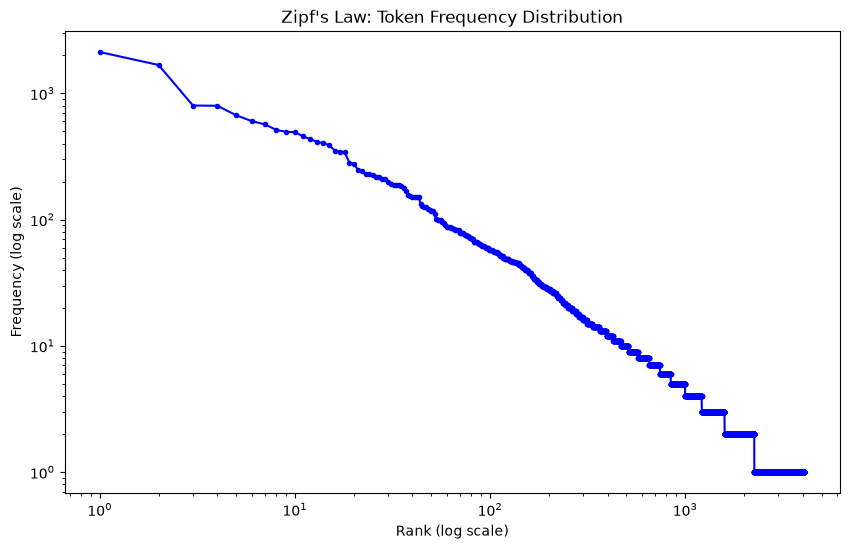

In [28]:

# Log-log plot
plt.figure(figsize=(10, 6))
plt.loglog(ranks, sorted_counts, marker=".", linestyle="-", color="blue")
plt.xlabel("Rank (log scale)")
plt.ylabel("Frequency (log scale)")
plt.title("Zipf's Law: Token Frequency Distribution")


Find the token equivalent of a hapax legomena (tokens with count == 1) - ironically this word is a hapax legomenon itself in this repository.

In [29]:
hapax_ids = unique_ids[counts == 1]

for token_id in hapax_ids[:10]:
    token = enc.decode([token_id])
    escaped_token = token.replace("\n", "\\n").replace("\t", "\\t").replace("\r", "\\r")
    print(f"Hapax legomenon: '{escaped_token}' (ID: {token_id})")

Hapax legomenon: '%' (ID: 4)
Hapax legomenon: 'C' (ID: 34)
Hapax legomenon: 'E' (ID: 36)
Hapax legomenon: 'M' (ID: 44)
Hapax legomenon: 'W' (ID: 54)
Hapax legomenon: 'c' (ID: 66)
Hapax legomenon: 'g' (ID: 70)
Hapax legomenon: 'i' (ID: 72)
Hapax legomenon: 'j' (ID: 73)
Hapax legomenon: 'k' (ID: 74)


## convert as spikes

Based of token IDs frequencies, one produce a codebook to encode any IDs. If we give the most frequent tokens the rows with the smallest weight, the expected activity (average number of active neurons per token) is minimal – reaching lowest Hamming distance (sparsest spiking activity).

In [30]:
def make_codebook(opt, token_ids):
    """
    token_ids : 1‑D numpy array of integer token ids (the whole corpus)

    Returns
        codebook  : torch.uint8 Tensor (num_unique, N_neuron)
        id2rank  : dict token‑id → rank (row index)
        rank2id  : dict rank     → token‑id
        bits2rank: dict tuple(active_neuron_idxs) → rank
    """
    N, dev = opt.N_neuron, opt.device

    # ----- most‑frequent → least‑frequent order -----
    uniq, cnt = np.unique(token_ids, return_counts=True)
    sorted_ids = uniq[np.argsort(-cnt)]          # (num_unique,)
    num_unique = len(sorted_ids)

    # ----- generate exactly `num_unique` masks (0, one‑hot, two‑hot) -----
    masks = [0]                                 # zero‑vector
    for i in range(N):                         # one‑hot
        if len(masks) >= num_unique: break
        masks.append(1 << i)
    if len(masks) < num_unique:                 # two‑hot (only if needed)
        for i in range(N):
            for j in range(i + 1, N):
                masks.append((1 << i) | (1 << j))
                if len(masks) >= num_unique: break
            if len(masks) >= num_unique: break
    assert len(masks) == num_unique

    # ----- integer mask → binary row (uint8) & bits2rank dict -----
    rows = []
    bits2rank = {}
    for r, m in enumerate(masks):
        bits = tuple(i for i in range(N) if (m >> i) & 1)   # (), (i,), (i,j)
        bits2rank[bits] = r
        rows.append(torch.tensor([(m >> i) & 1 for i in range(N)],
                                 dtype=torch.uint8, device=dev))
    codebook = torch.stack(rows, dim=0)                     # (num_unique, N)

    # ----- forward / reverse dictionaries -----
    id2rank = {int(t): r for r, t in enumerate(sorted_ids)}
    rank2id = {r: int(t) for r, t in enumerate(sorted_ids)}

    return codebook, id2rank, rank2id, bits2rank

def encode_batch(token_batch, codebook, id2rank, device):
    """
    token_batch : LongTensor
        (T,)  – single pattern
        (P,T)– P patterns stacked row‑wise
    Returns
        FloatTensor of shape (P, N_neuron, T)  (0.0 / 1.0)
    """
    tb = token_batch.to(device)

    # always work with a 2‑D view (P, T)
    if tb.dim() == 1:
        tb = tb.unsqueeze(0)                     # (1, T)

    P, T = tb.shape

    # token‑id → rank (plain Python dict lookup)
    flat_ranks = torch.tensor([id2rank[int(i)] for i in tb.reshape(-1).tolist()],
                              dtype=torch.long, device=device)

    # pick rows from the compact code‑book
    # -> (P·T, N_neuron)
    binary = codebook[flat_ranks]

    # reshape to (P, T, N_neuron) then permute to (P, N_neuron, T)
    binary = binary.view(P, T, -1).permute(0, 2, 1)

    return binary.float()

def decode_batch(binary, bits2rank, rank2id, device=opt.device):
    """
    binary : FloatTensor
        (P, N_neuron, T) – batch of patterns
        or (N_neuron, T) – single pattern
    Returns
        LongTensor of shape (P, T) (or (T,) for a single pattern)
    """
    b = binary.to(device)
    if b.dim() == 2:                 # (N, T) → single pattern
        b = b.unsqueeze(0)           # (1, N, T)
    P, N, T = b.shape

    flat = b.permute(0, 2, 1).reshape(-1, N)          # (P·T, N)

    # list of tuples: each tuple contains the positions of the 1‑bits
    bits = [tuple(row.nonzero(as_tuple=False).flatten().tolist())
            for row in flat]

    # tuple → rank → original token id, then reshape back
    ids = torch.tensor([rank2id[bits2rank[t]] for t in bits],
                       dtype=torch.long, device=device).view(P, T)

    # squeeze the leading dim if we only had a single pattern
    if P == 1:
        ids = ids.squeeze(0)          # shape (T,)

    return ids

In [31]:
filename = data_cache / f"{opt.datetag}_{exp}_codebook.pt"
if filename.exists() and not RECOMPUTE:
    ckpt = torch.load(filename, map_location=opt.device)
    codebook, id2rank, rank2id, bits2rank = ckpt["codebook"], ckpt["id2rank"], ckpt["rank2id"], ckpt["bits2rank"]
else:
    codebook, id2rank, rank2id, bits2rank = make_codebook(opt, token_ids)
    codebook = codebook.cpu()
    torch.save({"codebook": codebook,
                "id2rank":  id2rank,
                "rank2id":  rank2id,
                "bits2rank": bits2rank}, filename)
    codebook = codebook.to(opt.device)

codebook, id2rank, rank2id, bits2rank = make_codebook(opt, token_ids)
codebook.device

device(type='mps', index=0)

In [32]:
print("code‑book shape :", codebook.shape)   # (max_tokens, 256)
print("rank2id shape :", len(rank2id))   # (max_tokens,)
print("most frequent token → rank 0 :", rank2id[0])
print("second most frequent token → rank 1 :", rank2id[1])
print("third most frequent token → rank 2 :", rank2id[2])

code‑book shape : torch.Size([4080, 512])
rank2id shape : 4080
most frequent token → rank 0 : 11
second most frequent token → rank 1 : 279
third most frequent token → rank 2 : 323


In [33]:
text = "So she was considering in her own mind"
fox_tokens = enc.encode(text)
print("Token IDs :", fox_tokens)
print("Decoded   :", enc.decode(fox_tokens))
print("Token count:", len(fox_tokens))

Token IDs : [4516, 1364, 574, 13126, 304, 1077, 1866, 4059]
Decoded   : So she was considering in her own mind
Token count: 8


In [34]:

tok_tensor = torch.Tensor(fox_tokens).long().to(opt.device)        # shape (9,)
binary_single = encode_batch(tok_tensor, codebook, id2rank, opt.device)

print("tok_tensor shape :", tok_tensor.shape)   # (9,)
print("binary shape :", binary_single.shape)   # (256, 9)
print("First few rows (as 0/1) of the binary matrix:")
print(binary_single[:, :, :5])  # show first 5 tokens


tok_tensor shape : torch.Size([8])
binary shape : torch.Size([1, 512, 8])
First few rows (as 0/1) of the binary matrix:
tensor([[[0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 1., 0.],
         ...,
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0.]]], device='mps:0')


In [35]:
batch_tensor = torch.stack([tok_tensor, tok_tensor], dim=0)   # shape (2,9)
binary_batch = encode_batch(batch_tensor, codebook, id2rank, opt.device)

print("\nbinary (batch) shape :", binary_batch.shape)   # (256, 2, 9)



binary (batch) shape : torch.Size([2, 512, 8])


In [36]:
decoded_one = decode_batch(binary_single, bits2rank, rank2id)
print("\nDecoded (single) IDs :", decoded_one.tolist())
print("Round‑trip OK ?",
        np.array_equal(fox_tokens, decoded_one.cpu().numpy()))


Decoded (single) IDs : [4516, 1364, 574, 13126, 304, 1077, 1866, 4059]
Round‑trip OK ? True


In [37]:
print(f'decoded text = "{enc.decode(decoded_one.cpu().numpy())}"')

decoded text = "So she was considering in her own mind"


In [38]:
decoded_batch = decode_batch(binary_batch, bits2rank, rank2id)
print("\nDecoded (batch) shape :", decoded_batch.shape)    # (2, 9)
print("First pattern decoded :", decoded_batch[0].tolist())
print("Second pattern decoded :", decoded_batch[1].tolist())


Decoded (batch) shape : torch.Size([2, 8])
First pattern decoded : [4516, 1364, 574, 13126, 304, 1077, 1866, 4059]
Second pattern decoded : [4516, 1364, 574, 13126, 304, 1077, 1866, 4059]


## define the pattern generator

In [39]:
len(token_ids) - opt.N_time  + 1

37722

In [40]:
# token_ids = token_ids.cpu().numpy()

In [41]:
token_ids = np.array(token_ids, dtype=np.uint32)

In [42]:
# token_ids = torch.Tensor(token_ids).long().to(opt.device)        # shape (9,)
token_ids[:10]


array([62786,   753, 51679,   304, 90024,   198,  1729, 21256, 47209,
         198], dtype=uint32)

In [43]:
print(type(token_ids))          # torch.Tensor  OR  np.ndarray
print(len(token_ids))         # e.g. (30_000_000,)


<class 'numpy.ndarray'>
38721


In [44]:
seed = None
rng = np.random.default_rng(seed)
x= rng.choice(30, size=25, replace=False)
x.sort()
x

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8, 10, 13, 14, 15, 16, 17, 18, 19,
       20, 21, 22, 23, 26, 27, 28, 29])

In [45]:
rng = np.random.default_rng(42)
pattern_idxs_np = rng.choice(len(token_ids) - opt.N_time  + 1, size=opt.N_pattern, replace=False)
pattern_idxs_np

array([16550,  3365,  3551, 27751, 26300, 24683, 19857, 28710, 29651,
       27063, 16329,  3241, 32379, 36798, 29184,  7598])

In [46]:
pattern_idxs_np[:, None] + np.arange(opt.N_time)[None, :]

array([[16550, 16551, 16552, ..., 17547, 17548, 17549],
       [ 3365,  3366,  3367, ...,  4362,  4363,  4364],
       [ 3551,  3552,  3553, ...,  4548,  4549,  4550],
       ...,
       [36798, 36799, 36800, ..., 37795, 37796, 37797],
       [29184, 29185, 29186, ..., 30181, 30182, 30183],
       [ 7598,  7599,  7600, ...,  8595,  8596,  8597]], shape=(16, 1000))

In [47]:
batch = token_ids[ pattern_idxs_np[:, None] + np.arange(opt.N_time)[None, :] ]
batch.shape

(16, 1000)

In [48]:
pprint('DEFINING THE PATTERN GENERATOR: Creating a spike pattern generator for text data')

DEFINING THE PATTERN GENERATOR: Creating a spike pattern generator for text data


In [49]:
cb = {"codebook": codebook, "id2rank":  id2rank, "rank2id":  rank2id, "bits2rank": bits2rank}

In [50]:
import secrets
seed = secrets.randbits(64)
seed

7743112742373851379

In [51]:
class TextSpikingPattern(SpikingPattern):
    def __init__(self, token_ids, cb):
        super().__init__()
        self.desc = "A text spike pattern generator"
        self.token_ids = token_ids # the full corpus as a list of token IDs
        self.n_token = len(token_ids)
        self.cb = cb


    def __call__(self, seed=None, verbose=False):
        """
        Generate N_pattern realizations of length N_time from the spiking pattern of the whole corpus.

        """
        if seed is None:
            if verbose: print("Using default seed from options")
            import secrets
            seed = secrets.randbits(64)
            # seed = self.opt.seed
        rng = np.random.default_rng(seed)
        # create a batch of random starting indices for the patterns
        pattern_idxs_np = rng.choice(self.n_token - self.opt.N_time  + 1, size=self.opt.N_pattern, replace=False)
        # pattern_idxs = torch.from_numpy(pattern_idxs_np)
        # create a batch of token IDs for the selected patterns
        batch_tensor = token_ids[ pattern_idxs_np[:, None] + np.arange(opt.N_time)[None, :] ]
        batch_tensor = torch.from_numpy(batch_tensor)
        # encode the batch of token IDs into spikes using the codebook
        spikes = encode_batch(batch_tensor, self.cb['codebook'], self.cb['id2rank'], self.opt.device)

        if verbose:
            print("\nEncoded (batch) shape :", spikes.shape)
            print("First pattern encoded :", spikes[0, :, :5])  # show first 5 tokens of the first pattern

            decoded_batch = decode_batch(spikes, self.cb['bits2rank'], self.cb['rank2id'])
            print("\nDecoded (batch) shape :", decoded_batch.shape)    
            print("First pattern decoded :", decoded_batch[0].tolist()[:100])
            print("Decoded   :", enc.decode(decoded_batch[0].tolist())[:100])

            # print("Second pattern decoded :", decoded_batch[1].tolist())
        return spikes

tsp = TextSpikingPattern(token_ids, cb)
tsp.init(opt)
spike_pattern = tsp()
spike_pattern.shape

torch.Size([16, 512, 1000])

In [52]:
spike_pattern = tsp(seed=42, verbose=True)
spike_pattern.shape


Encoded (batch) shape : torch.Size([16, 512, 1000])
First pattern encoded : tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        ...,
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]], device='mps:0')

Decoded (batch) shape : torch.Size([16, 1000])
First pattern decoded : [1364, 6137, 11, 4856, 99149, 398, 11, 439, 1364, 1550, 539, 520, 682, 1440, 3508, 433, 1053, 1093, 279, 836, 25, 4869, 11, 433, 1193, 88379, 264, 2697, 22622, 13, 1054, 29951, 11, 433, 753, 18949, 779, 3117, 2476, 3463, 30505, 11, 323, 1364, 4024, 389, 13, 1054, 29089, 499, 3371, 757, 11, 4587, 11, 902, 1648, 358, 22525, 311, 733, 505, 1618, 12671, 198, 49977, 14117, 264, 1695, 3568, 389, 1405, 499, 1390, 311, 636, 311, 2476, 1071, 279, 17810, 627, 10378, 1541, 1431, 1790, 2512, 1405, 2345, 863, 1071, 30505, 627, 2118, 12487, 433, 3250, 1431, 5030, 902]
Decoded   :  she began, rather timidly, as she did not at all know whether it wo

torch.Size([16, 512, 1000])

## Learn the target

In [53]:
pprint('LEARNING THE TARGET: Training the spiking neural network to learn Wikipedia text patterns')

LEARNING THE TARGET: Training the spiking neural network to learn Wikipedia text patterns


In [54]:
hd = HD_SNN(opt, TextSpikingPattern(token_ids, cb))
hd.target().shape, opt.N_neuron, opt.N_time

(torch.Size([16, 512, 1000]), 512, 1000)

In [55]:
opt

Params(datetag='2026-08-06', N_neuron=512, num_delay=61, N_pattern=16, N_time=1000, N_pretime=0, p_A=0.0, p_flip=0.01, seed=2018, lif_beta=0.4, lif_threshold=0.8, learn_beta=False, learn_threshold=False, do_pinv=True, do_deconv=True, num_epochs=1024, num_warmup_epochs=16, base_lr=0.03, final_lr=0.001, delta1=0.01, delta2=1e-05, dropout=0.25, alpha_surrogate=5.0, surrogate_name='FastSigmoid', loss_name='SpikeF1scoreLoss', reset_mechanism='subtract', optimizer='sgd', verbose=False, fig_width=30, fig_height=15, phi=1.61803, N_time_show=512, N_neuron_show=200, N_scan=36)

In [56]:
model_init_filename = data_cache / f"{hd.opt.datetag}_{exp}_weights_init.pth"
lock_filename = model_init_filename.with_suffix('.lock')
if RECOMPUTE:
    model_init_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
    lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
try:
    model_state_dict = torch.load(model_init_filename, map_location=torch.device(hd.opt.device))
    hd.net.load_state_dict(model_state_dict)
    hd.net.eval()
    lock_filename.unlink(missing_ok=True) # in case the lock file was not unlinked
    print(f"Model weights loaded from {model_init_filename}") # Add a log message
except FileNotFoundError:
    if not lock_filename.exists():
        print(f"Model file not found: {model_init_filename}, inititializing the new model.")
        lock_filename.touch(exist_ok=True)
        ##################
        hd.update_weight()
        ##################
        torch.save(hd.net.state_dict(), model_init_filename)
        lock_filename.unlink(missing_ok=True)
    else:
        print(f"Model file is locked: {lock_filename}, passing.")

Model file not found: ../cached_data/2026-08-06_text_alice_weights_init.pth, inititializing the new model.


In [ ]:
if not lock_filename.exists():
    model_filename = data_cache / f"{hd.opt.datetag}_{exp}_weights.pth"
    lock_filename = model_filename.with_suffix('.lock')
    if RECOMPUTE:
        model_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
        lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
    try:
        model_state_dict = torch.load(model_filename, map_location=torch.device(hd.opt.device))
        hd.net.load_state_dict(model_state_dict)
        hd.net.eval()
        lock_filename.unlink(missing_ok=True) # in case the lock file was not unlinked
        print(f"Model weights loaded from {model_filename}") # Add a log message
    except FileNotFoundError:
        model_state_dict = torch.load(model_init_filename, map_location=torch.device(hd.opt.device))
        hd.net.load_state_dict(model_state_dict)
        if not lock_filename.exists():
            print(f"Model file not found: {model_filename}, learning the new model.")
            lock_filename.touch(exist_ok=True)
            ##################
            hd.learn_model()
            ##################
            torch.save(hd.net.state_dict(), model_filename)
            lock_filename.unlink(missing_ok=True)
        else:
            print(f"Model file is locked: {lock_filename}, passing.")

Model file not found: ../cached_data/2026-08-06_text_alice_weights.pth, learning the new model.
Train Epoch [000016/001024]	| Loss = 6.550e-01	| precision = 0.998	| recall = 0.214	| f1_score = 0.345	| 
Train Epoch [000032/001024]	| Loss = 7.206e-01	| precision = 0.997	| recall = 0.167	| f1_score = 0.279	| 


In [ ]:
opt.p_A

In [ ]:
with torch.no_grad():
    target = hd.target()
    target_full = torch.nn.functional.pad(target, (opt.N_pretime, opt.N_pretime))
    input_spikes = hd.get_input_spikes(target=target, p_A=opt.p_A)
    _, _, output_spikes = hd.forward_pass(input_spikes)
    spikes_evoked = output_spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(hd.opt.N_time+hd.opt.N_pretime)]
    target_evoked = target[:, :, hd.opt.num_delay:]

    precision, recall, f1_score = get_scores(spikes_evoked, target_evoked)
    # precision, recall, f1_score = get_scores(output_spikes, target_full)
    print(f'precision = {precision:.3f}\t recall = {recall:.3f}\t f1_score = {f1_score:.3f} ')

In [ ]:
fig, ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
# opt.N_neuron_show = opt.N_neuron
opt.N_time_show = opt.N_time //4 
splt.raster(output_spikes[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="blue", marker='+', alpha=.5)
splt.raster(target_full[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.5)
splt.raster(input_spikes[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="green", marker='x', alpha=.5)
ax.vlines([opt.N_pretime], 0, opt.N_neuron_show, 'r', ls='--')
ax.vlines([opt.N_pretime+opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_xlim(-1., opt.N_time_show + 1.)
ax.set_ylim(-1., opt.N_neuron_show + 1.)
output_spikes.shape, output_spikes[i_pattern, :, :].sum().item(), target_full[i_pattern, :, :].sum().item()

In [ ]:
output_spikes.shape

In [ ]:
output_spikes[:, :, :(hd.opt.N_pretime+hd.opt.num_delay)] = input_spikes[:, :, :(hd.opt.N_pretime+hd.opt.num_delay)]

In [ ]:
decoded_spike_ids = decode_batch(output_spikes[i_pattern, :, :], bits2rank, rank2id)
decoded_spike_ids

In [ ]:
# print("| Decoded trigger :", enc.decode(decoded_spike_ids[:opt.num_delay].cpu().numpy())[:500], end="|\t|")
# print("Decoded prediction :", enc.decode(decoded_spike_ids[opt.num_delay:].cpu().numpy())[:500], '|')

In [ ]:
# print("| Decoded trigger :", escaped_text(enc.decode(decoded_spike_ids[:opt.num_delay].cpu().numpy())), end="|")
# print(" prediction :", escaped_text(enc.decode(decoded_spike_ids[opt.num_delay:].cpu().numpy())), '|')

In [ ]:
print("\033[31mRed text\033[0m")
print("\033[32mGreen text\033[0m")
print("\033[34mBlue text\033[0m")

In [ ]:
for i_pattern_ in range(opt.N_pattern):
    decoded_spike_ids = decode_batch(output_spikes[i_pattern_, :, :], bits2rank, rank2id)
    print(f"| \033[32mDecoded trigger : {escaped_text(enc.decode(decoded_spike_ids[:opt.num_delay].cpu().numpy()))}\033[0m|\033[34mprediction | : {escaped_text(enc.decode(decoded_spike_ids[opt.num_delay:].cpu().numpy())[:200])} \033[0m|")

## Encode, trigger the net, retrieve spikes and then decode text


reconstruct text from the spikes and compare with the original text. This will require a mapping from neuron addresses back to token IDs and then decoding those token IDs back to text using the tokenizer.


In [ ]:
test_text =  4*" " + NeuroComp_text
test_text[:1000]

In [ ]:
text_token_ids = enc.encode(test_text)
print("Token IDs :", text_token_ids[:500])

In [ ]:
tok_tensor = torch.Tensor(text_token_ids).long().to(opt.device)        # shape (9,)
print("tok_tensor shape :", tok_tensor.shape)   # (9,)
target = encode_batch(tok_tensor, codebook, id2rank, opt.device)
# target_full = torch.nn.functional.pad(target, (opt.N_pretime, opt.N_pretime))
print("target_full shape :", target.shape)   # (9, 256)

In [ ]:
decoded_spike_ids = decode_batch(target[0, :, :], bits2rank, rank2id)
decoded_spike_ids

In [ ]:
print("| Decoded trigger |", escaped_text(enc.decode(decoded_spike_ids[:opt.num_delay].cpu().numpy())), end="|\n")
print("| to predict  =   |", escaped_text(enc.decode(decoded_spike_ids[opt.num_delay:].cpu().numpy())), '|')

In [ ]:
# input_spikes = target_full
input_spikes = torch.zeros_like(target)
input_spikes[:, :, (opt.num_delay):] = 0 
input_spikes[:, :, opt.N_pretime:(opt.N_pretime+opt.num_delay)] = target[:, :, :opt.num_delay]
# input_spikes = hd.get_input_spikes(target)
print("input_spikes shape :", input_spikes.shape)

In [ ]:
decoded_spike_ids = decode_batch(input_spikes, bits2rank, rank2id)
print("| Decoded trigger |", escaped_text(enc.decode(decoded_spike_ids[:opt.num_delay].cpu().numpy())), end="|\n")
print("| to predict  =   |", escaped_text(enc.decode(decoded_spike_ids[opt.num_delay:].cpu().numpy())), '|')

In [ ]:
_, _, output_spikes = hd.forward_pass(input_spikes)
print("spikes shape :", output_spikes.shape)   # (9, 256)

In [ ]:
output_spikes[:, :, :(hd.opt.N_pretime+hd.opt.num_delay)] = input_spikes[:, :, :(hd.opt.N_pretime+hd.opt.num_delay)]

In [ ]:
print("First few rows (as 0/1) of the binary matrix:")
print(output_spikes[:, :, :5])  # show first 5 tokens

In [ ]:
decoded_ids = decode_batch(output_spikes, bits2rank, rank2id)
print("Token count:", len(text_token_ids))
print("\nDecoded (single) IDs :", decoded_ids.tolist()[:500])
print("Round‑trip OK ?",
        np.array_equal(fox_tokens, decoded_ids.cpu().numpy()))

In [ ]:
print(f'decoded text = "{enc.decode(decoded_ids.cpu().numpy())}"')

In [ ]:
fig, ax = plt.subplots(figsize=(opt.fig_width, opt.fig_width/phi))
opt.N_neuron_show = opt.N_neuron
opt.N_time_show = opt.N_time
splt.raster(output_spikes[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="blue", marker='+', alpha=.5)
splt.raster(target[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='none', edgecolor='red',  marker='o', alpha=.5)
splt.raster(input_spikes[i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, c="green", marker='x', alpha=.5)
ax.vlines([opt.num_delay], 0, opt.N_neuron_show, 'b', ls='--')
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
output_spikes.shape, output_spikes[i_pattern, :, :].sum().item(), target[i_pattern, :, :].sum().item()

## optimizing learning parameters with optuna

In [ ]:
pprint('OPTIMIZING LEARNING PARAMETERS WITH OPTUNA: Hyperparameter optimization using Bayesian search')


In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import warnings
warnings.filterwarnings("ignore", category=optuna.exceptions.ExperimentalWarning,)
optuna_filename = data_cache / f"{opt.datetag}_{exp}_optuna.sqlite3"
lock_filename, study = optuna_filename.with_suffix('.lock'), 1
if RECOMPUTE:
    optuna_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
    lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE
%ls -l {optuna_filename}

In [ ]:
def objective(trial):    
    new_opt = Params(**opt_dict)

    new_opt.do_deconv = trial.suggest_categorical('do_deconv', [True, False])
    # new_opt.do_pinv = trial.suggest_categorical('do_pinv', [True, False])
    new_opt.learn_beta = trial.suggest_categorical('learn_beta', [True, False])
    new_opt.learn_threshold = trial.suggest_categorical('learn_threshold', [True, False])
    new_opt.reset_mechanism = trial.suggest_categorical('reset_mechanism', ['zero', 'subtract'])
    new_opt.optimizer = trial.suggest_categorical('optimizer', ['adamw', 'rmsprop', 'adadelta', 'sgd', 'adam']) # 'adagrad', 'sparseadam', 

    # new_opt.surrogate_name = trial.suggest_categorical('surrogate_name', ['FastSigmoid', 'LeakySpikeOperator', 'ATan', 'Sigmoid', 'SpikeRateEscape'])
    # new_opt.loss_name = trial.suggest_categorical('loss_name', [  'SpikeF1scoreLoss', 'MSELoss', 'L1Loss'])

    new_opt.lif_beta = trial.suggest_float('lif_beta', 0, 1)
    scale = 10
    scale = 3.618    
    new_opt.alpha_surrogate = trial.suggest_float('alpha_surrogate', new_opt.alpha_surrogate / scale, new_opt.alpha_surrogate * scale, log=True)
    new_opt.base_lr = trial.suggest_float('base_lr', new_opt.base_lr / scale, new_opt.base_lr * scale, log=True)
    new_opt.final_lr = trial.suggest_float('final_lr', new_opt.final_lr / scale, new_opt.final_lr * scale, log=True)
    new_opt.delta1 = trial.suggest_float('delta1', new_opt.delta1 / scale, min((new_opt.delta1 * scale, .99)), log=True)
    new_opt.delta2 = trial.suggest_float('delta2', new_opt.delta2 / scale, min((new_opt.delta2 * scale, .99)), log=True)
    new_opt.dropout = trial.suggest_float('dropout', 0, 1)
    new_opt.lif_threshold = trial.suggest_float('lif_threshold', new_opt.lif_threshold / scale, new_opt.lif_threshold * scale, log=True)

    try:
        hd = HD_SNN(new_opt, TextSpikingPattern(token_ids, cb))
        # hd.update_weight() # HACK 
        hd.learn_model(verbose=False)
        
        with torch.no_grad():
            # draw causes (SMs) - hidden to the observer
            target_ = hd.target()
            input_spikes = hd.get_input_spikes(target=target_)
            _, _, spikes = hd.forward_pass(input_spikes)
            spikes_ = spikes[:, :, (hd.opt.N_pretime+hd.opt.num_delay):(hd.opt.N_time+hd.opt.N_pretime)]
            target_ = target_[:, :, hd.opt.num_delay:]
            loss_val = loss_fn(spikes_, target_)

        return loss_val.item()
    except Exception as e:
        print(f"Error occurred: {e}")
        return 1.
        
N_optuna_scan = 100
N_optuna_scan = 200
# N_optuna_scan = 1000
N_optuna_scan = 200 // DEBUG**2

if not lock_filename.exists():
    # 3. Create a study object and optimize the objective function.
    study = optuna.create_study(
        storage=f"sqlite:///{str(optuna_filename)}",
        sampler=optuna.samplers.TPESampler(multivariate=True, warn_independent_sampling=False),
        direction="minimize",
        load_if_exists=True,
        study_name=opt.datetag,
    )

    if len(study.trials) < N_optuna_scan:
        print(f"Optuna file not found or unlocked: {optuna_filename}, starting optimization.")
        lock_filename.touch(exist_ok=True)

        if len(study.trials)>0:
            print("So far, Best params: ", study.best_params, end=', ')
            print("Best value: ", study.best_value)

        print(
            f"Starting optimization on {max(N_optuna_scan - len(study.trials), 0)} trials with {len(study.trials)} existing trials."
        )
        study.optimize(objective, n_trials=max((N_optuna_scan - len(study.trials), 0)), n_jobs=1, show_progress_bar=True)
        lock_filename.unlink(missing_ok=True)
else:
    print(f"Optuna file is locked: {lock_filename}, passing.")
    study = None

In [ ]:
if not study is None:
    study = optuna.load_study(storage=f"sqlite:///{str(optuna_filename)}", study_name=opt.datetag)
else:
    if not lock_filename.exists():
        print("Study is None (not due to lock), skipping load.")
    else:   
        print(f"Optuna file is locked: {lock_filename}, passing.")
    

In [ ]:
if not study is None:
    print(f'number of trials in study: {len(study.trials)}')
else:
    print("Study is None, skipping trials display.")

In [ ]:
if not study is None:
    print(50 * "-.")
    print("Best params: ", study.best_params)
    print("Best value: ", study.best_value)
    # print("Best Trial params: ", study.best_trial.params)
else:
    print("Study is None, skipping best-trial summary.")

In [ ]:
if not study is None: 
    import numpy as np
    print("=" * 60)
    print("OPTUNA STUDY ANALYSIS")
    print("=" * 60)

    # 1. Parameter Importances (Ranking of Most Important Parameters)
    print("\n[1] PARAMETER IMPORTANCE RANKING:")
    try:
        importance_dict = optuna.importance.get_param_importances(study)
        for param, imp in sorted(importance_dict.items(), key=lambda item: item[1], reverse=True):
            print(f"{param:<30}: {imp:.3f}")
    except Exception as e:
        print("Error computing importance:", str(e))

    # 2. Best Value and Confidence Intervals for Each Parameter
    print("\n[2] BEST VALUES WITH CONFIDENCE INTERVALS:")

    if not study.trials:
        print("No trials found.")
    else:
        best_trial = study.best_trial
        print(f"\nBest Objective Value: {best_trial.value:.5f}")

        # Collect all valid trials
        completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

        if not completed_trials:
            print("No completed trials available.")
        else:
            # Get top 10% performing trials for confidence interval estimation
            top_trials = sorted(completed_trials, key=lambda t: t.value, reverse=True)[:max(1, len(completed_trials) // 10)]

            params_all = {pname: [] for pname in best_trial.params}
            for trial in top_trials:
                for pname in params_all:
                    if pname in trial.params:
                        params_all[pname].append(trial.params[pname])

            print("\nEstimated Confidence Intervals (Top 10% Trials):")
            for pname in best_trial.params:
                vals = params_all.get(pname, [])
                if vals:
                    # Check if values are boolean
                    if isinstance(vals[0], bool):
                        # For boolean parameters, show mode and frequency
                        true_count = sum(1 for v in vals if v)
                        false_count = len(vals) - true_count
                        most_common = True if true_count >= false_count else False
                        print(f"{pname}\t: Best={best_trial.params[pname]},\t "
                            f"Most Common={most_common}, True: {true_count}/{len(vals)} ({100*true_count/len(vals):.1f}%)")
                    else:
                        # For numeric parameters, compute percentiles
                        try:
                            low = np.percentile(vals, 5)
                            high = np.percentile(vals, 95)
                            median = np.median(vals)
                            print(f"{pname}\t: Best={best_trial.params[pname]:3e},\t "
                                f"Median={median:>8.3e}, 90% CI=[{low:>8.3e}, {high:>8.3e}]")
                        except Exception as e:
                            print(f"{pname}\t: Best={best_trial.params[pname]},\t "
                                f"Error computing stats: {str(e)}")
                else:
                    print(f"{pname:<30}: No data")

    print("\n" + "=" * 60)

In [ ]:
if not study is None:
    import optuna.visualization.matplotlib as vis
    vis.plot_param_importances(study)
else:
    print("Study is None, skipping parameter-importance plot.")

In [ ]:
if study is not None:

    params = sorted({k for t in study.trials for k in t.params})
    fig, axes = plt.subplots(len(params), 1, figsize=(opt.fig_width, opt.fig_width / phi * len(params)), sharey=True)

    # Garantit un itérable même s'il n'y a qu'un seul paramètre
    if len(params) == 1:
        axes = [axes]

    for ax, pname in zip(axes, params):
        xs = [t.params[pname] for t in study.trials if pname in t.params]
        ys = [t.value for t in study.trials if pname in t.params]

        df = pd.DataFrame({"x": xs, "y": ys})

        # Détection explicite du cas binaire (ex: do_deconv, do_pinv)
        unique_vals = set(df["x"].dropna().tolist())
        is_binary = unique_vals.issubset({True, False, 0, 1}) and len(unique_vals) <= 2
        is_numeric = pd.api.types.is_numeric_dtype(df["x"])

        if is_binary:
            df["x"] = df["x"].astype(bool).map({False: "False", True: "True"})
            ax.scatter(df["x"], df["y"], s=24, alpha=0.8, color="tab:blue", label="Trials")
        elif is_numeric:
            if len(df["x"].unique()) > 1:
                sns.regplot(
                    x="x", y="y", data=df, ax=ax, lowess=True, color="red",
                    line_kws={"lw": 2, "label": "Tendance (LOWESS)"}, scatter=False
                )
            ax.scatter(df["x"], df["y"], s=20, alpha=0.7, color="blue", label="Trials")

            # L'échelle log sur x n'est valide que pour des valeurs strictement positives
            if (df["x"] > 0).all():
                ax.set_xscale("log")
        else:
            df["x"] = df["x"].astype(str)
            ax.scatter(df["x"], df["y"], s=20, alpha=0.7, color="blue", label="Trials")

        ax.set_xlabel(pname)
        ax.set_ylabel("Objective")
        ax.set_yscale("log")

    plt.tight_layout()
else:
    print("Study is None, skipping diagnostic plots.")

## scanning parameters



In [ ]:
pprint('SCANNING PARAMETERS: Systematic evaluation of network and stimulus parameters on model performance')


In [ ]:
import time
opt_scan = Params(datetag = f'{opt.datetag}_{exp}_scan', 
                #   fig_width = 3.25, 
                  **opt_dict)

N_scanning = 13 // DEBUG

scan_dicts= {'N_pattern' : np.linspace(1, 64, N_scanning, dtype=int),
             'N_time' : np.geomspace(500, 3000, N_scanning, dtype=int), #[2**k for k in range(6, 12)],
             'num_delay' : np.linspace(1, 100, N_scanning, dtype=int), # [2, 3, 5, 8, 13, 21, 34, 55, 89],
             'N_neuron' : 2 * np.geomspace(50, 2000, N_scanning, dtype=int), # [55, 89, 144, 233, 377, 610, 987, 1364], #13, 21, 34, 
            #  'p_A': np.geomspace(0.0002, 0.05, N_scanning, dtype=float) , # [0.0002, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05], #0.00001, 0.00002, 0.00005, 0.0001, .. , 0.1, 0.5
             'lif_threshold': np.linspace(0.6, 1.05, N_scanning, dtype=float), 
             'do_deconv' : [True, False],
             'do_pinv' : [True, False],
            }
label_dicts= {'N_pattern' : 'number of patterns',
             'N_time' : 'Pattern duration',
             'num_delay' : 'Delay range',
             'N_neuron' : 'Presynaptic inputs',
             'p_A': 'Average firing',
             'lif_threshold': 'LIF threshold',
             'do_deconv' : 'Membrane deconvolution',
             'do_pinv' : 'Full pseudo-inverse computation',
            }

N_cv = 10
N_cv = 2
seed = opt_scan.seed
verb = True

for key in scan_dicts:
    print(f"{50*'-'}\nscanning {key=}\n{50*'-'}", )
    filename = data_cache / f'{opt_scan.datetag}_{key}.json'
    lock_filename = filename.with_suffix('.lock')
    if RECOMPUTE: 
        filename.unlink(missing_ok=True) # FORCING RECOMPUTE
        lock_filename.unlink(missing_ok=True) # FORCING RECOMPUTE

    if filename.exists():
        df_scan = pd.read_json(filename, orient='records')
    else:
        measure_columns = [key, 'i_cv', 'loss', 'time']
        df_scan = pd.DataFrame([], columns=measure_columns)

    if not lock_filename.exists():
        lock_filename.touch(exist_ok=True)
        # checking if everything is already computed
        i_loc = 0
        verb = False
        # do print the progress if any item is not computed
        verb = any(((df_scan[key] == value) & (df_scan["i_cv"] == i_cv)).empty 
                   for value in scan_dicts[key] for i_cv in range(N_cv))
        for i_value, value in enumerate(scan_dicts[key]):
            for i_cv in range(N_cv):
                # Check if there's already a row with the same key value and i_cv
                mask = approx_equals(df_scan[key], value) & (df_scan["i_cv"] == i_cv)

                if df_scan[mask].empty :
                    if verb: print(f'|{i_cv=}| {i_value + 1}/{len(scan_dicts[key])}', end='\t')
                    # create a new row with time zero to allow concurrent access to the file by other processes
                    df_scan.loc[i_loc] = {key:value, 'i_cv':i_cv, 'loss':float('inf'), 'time':0.0}
                    df_scan.to_json(filename, orient='records', indent=2)

                    # tic
                    since = time.time()
                    new_dict = asdict(opt_scan)
                    new_dict[key] = value
                    new_dict['seed'] = seed
                    seed += 1 # to have a different seed for each CV, but still reproducible                    
                    new_opt = Params(**new_dict)
                    codebook_, id2rank_, rank2id_, bits2rank_ = make_codebook(new_opt, token_ids)
                    new_cb = {"codebook": codebook_, "id2rank":  id2rank_, "rank2id":  rank2id_, "bits2rank": bits2rank_}
                    new_hd = HD_SNN(new_opt, TextSpikingPattern(token_ids, new_cb))
            
                    new_hd.update_weight()
                    new_hd.learn_model(verbose=False)

                    # test it
                    try:
                        with torch.no_grad():
                            target_ = new_hd.target()
                            input_spikes = new_hd.get_input_spikes(target=target_, p_A=new_hd.opt.p_A, N_pretime=new_hd.opt.N_pretime, N_trigger_time=new_hd.opt.num_delay, N_time=new_hd.opt.N_time)
                            _, _, spikes = new_hd.forward_pass(input_spikes)
                            spikes_ = spikes[:, :, (new_hd.opt.N_pretime+new_hd.opt.num_delay):(-new_hd.opt.N_pretime)]
                            loss_val = loss_fn(spikes_, target_[:, :, new_hd.opt.num_delay:]).item()
                    except Exception as e:
                        print(f"Error during evaluation: {e}")
                        loss_val = float('inf')  # Assign a large loss value to indicate failure
                        
                    # toc
                    elapsed_time = time.time() - since
        
                    if verb: 
                        print(f'|{key=}:{value=:.3e} \t| loss={loss_val:.3f}', end='\t')
                        print(f"| completed in {elapsed_time // 60:.1f}m {elapsed_time % 60:.1f}s |")

                    df_scan = pd.read_json(filename, orient='records')
                    mask = approx_equals(df_scan[key], value) & (df_scan["i_cv"] == i_cv)
                    df_scan[['loss', 'time']] = df_scan[['loss', 'time']].astype(float)
                    df_scan.loc[mask, ['loss', 'time']] = [loss_val, elapsed_time]
                    df_scan.to_json(filename, orient='records', indent=2)
                else:
                    if verb: 
                        print(f'|{key=}:{value=:.3e} \t| already computed for i_cv={i_cv}, skipping.', end='\t')
                        print(f"| completed in {df_scan[mask]['time'].values[0] // 60:.1f}m {df_scan[mask]['time'].values[0] % 60:.1f}s |")
                i_loc += 1
        lock_filename.unlink(missing_ok=True)


In [ ]:
from matplotlib import ticker
subplotpars_scan = SubplotParams(left=0.125, right=.95, bottom=0.25, top=.975)
custom_style = {
    'axes.spines.left': True,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'axes.spines.bottom': True,
}

for key in scan_dicts:
    print(f"{50*'-'}\nscanning {key=}\n{50*'-'}", )
    filename = data_cache / f'{opt_scan.datetag}_{key}.json'
    lock_filename = filename.with_suffix('.lock')
    if not lock_filename.exists() and filename.exists():
        print(f'Reading {filename=}...')
        df_scan = pd.read_json(filename)
        print(df_scan)
        # https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html?highlight=errorbar#visualization-errorbars
        fig, ax = plt.subplots(subplotpars=subplotpars_scan)
        gp_scan = df_scan[[key, 'loss']].groupby([key])
        means = gp_scan.mean()
        errors = gp_scan.std()

        with plt.style.context(custom_style):
            means.plot.bar(yerr=errors, ax=ax, capsize=4, rot=-60, legend=False, alpha=.5)

        ax.set_ylabel('Loss')
        ax.set_xlabel(label_dicts[key])

        # ax.set_xscale('logit')
        ax.set_ylim(0, 1)
        if key in ['p_A']:
            ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
            ax.xaxis.get_major_formatter().set_scientific(True)
            ax.xaxis.get_major_formatter().set_powerlimits((0,0))
        #fig = ax.get_figure()
        printfig(fig, f'scan_{exp}_{key}', fig_height=opt_scan.fig_height, fig_width=opt_scan.fig_width, figpath=figpath)
